# Devoir 1 - Vérification de code

#### A) Modification du code pour problème instationnaire: 

Mise en situation :

L'EDO de base à résoudre : 

$$\frac{\partial C}{\partial t} = D_{eff} \nabla^2 C - S$$

L'EDO avec une réaction de première ordre:

$$\frac{\partial C}{\partial t} = D_{eff} \nabla^2 C - kC$$

L'EDO réduite à une dimension :

$$\frac{\partial C}{\partial t} = D_{\mathrm{eff}}\left(\frac{1}{r}\frac{\partial}{\partial r}\!\left(r\,\frac{\partial C}{\partial r}\right)\right) - kC$$

L'EDO développée :

$$\frac{\partial C}{\partial t} = D_{\mathrm{eff}}\left(\frac{\partial ^2C}{\partial r^2} + \frac{1}{r}\frac{\partial C}{\partial r}\right) - kC$$


##### i. Préciser l'équation en chaque noeuds pour un schéma temporel implicite au pas de temps t et un nombre total de noeuds $N_{tot} = 5$

**Réponse :** 

**Noeud 1** : Ce noeud est un noeud frontière puisqu'il se trouve à $r = 0$. On y applique donc la condition frontière de symétrie tout comme la question E du devoir 1 (Avec un schema Gear avant):

$\left.\frac{\partial C}{\partial r}\right|_{r=0, t+1} = 0 \Longrightarrow \left.\frac{\partial C}{\partial r}\right|_{i=1, t+1} = \frac{-C_{i+2}^{t+1} + 4C_{i+1}^{t+1}-3C_i^{t+1}}{2\Delta r} = 0$

Pour $i=1$ l'équation devient donc :

$\frac{-C_{3}^{t+1} + 4C_{2}^{t+1}-3C_1^{t+1}}{2\Delta r} = 0 \Longrightarrow -C_{3}^{t+1} + 4C_{2}^{t+1}-3C_1^{t+1} = 0$

**Noeud 2, 3, 4** : Ces noeuds sont des noeuds intermédiaires. On applique donc l'équation trouvé après développement :

$\frac{\partial C}{\partial t} = D_{\mathrm{eff}}\left(\frac{\partial ^2C}{\partial r^2} + \frac{1}{r}\frac{\partial C}{\partial r}\right) - kC \Longrightarrow \frac{C_{i}^{t+1} - C_{i}^t}{\Delta t} = D_{\mathrm{eff}}\left(\frac{C_{i+1}^{t+1} - 2 C_i^{t+1} + C_{i-1}^{t+1}}{\Delta r^2} + \frac{1}{r_i}\frac{C_{i+1}^{t+1} - C_{i-1}^{t+1}}{2 \Delta r}\right) - kC_i^{t+1} \Longrightarrow \left( \Delta r^2 + 2 \Delta t D_{\mathrm{eff}} + k\Delta r^2 \Delta t \right) C_i^{t+1} - \Delta t D_{\mathrm{eff}} \left( 1 + \frac{\Delta r}{2r_i} \right) C_{i+1}^{t+1} - \Delta t D_{\mathrm{eff}} \left( 1 - \frac{\Delta r}{2r_i} \right) C_{i-1}^{t+1} = \Delta r^2 C_i^t$

Pour $i=2$ l'équation devient donc :

$$\left( \Delta r^2 + 2 \Delta t D_{\mathrm{eff}} + k\Delta r^2 \Delta t \right) C_2^{t+1} - \Delta t D_{\mathrm{eff}} \left( 1 + \frac{\Delta r}{2r_2} \right) C_{3}^{t+1} - \Delta t D_{\mathrm{eff}} \left( 1 - \frac{\Delta r}{2r_2} \right) C_{1}^{t+1} = \Delta r^2 C_2^t$$

Pour $i=3$ l'équation devient donc :

$$\left( \Delta r^2 + 2 \Delta t D_{\mathrm{eff}} + k\Delta r^2 \Delta t \right) C_3^{t+1} - \Delta t D_{\mathrm{eff}} \left( 1 + \frac{\Delta r}{2r_3} \right) C_{4}^{t+1} - \Delta t D_{\mathrm{eff}} \left( 1 - \frac{\Delta r}{2r_3} \right) C_{2}^{t+1} = \Delta r^2 C_3^t$$

Pour $i=4$ l'équation devient donc :

$$\left( \Delta r^2 + 2 \Delta t D_{\mathrm{eff}} + k\Delta r^2 \Delta t \right) C_4^{t+1} - \Delta t D_{\mathrm{eff}} \left( 1 + \frac{\Delta r}{2r_4} \right) C_{5}^{t+1} - \Delta t D_{\mathrm{eff}} \left( 1 - \frac{\Delta r}{2r_4} \right) C_{3}^{t+1} = \Delta r^2 C_4^t$$


**Noeud 5** : Ce noeud est un noeud frontière puisqu'il se trouve à $r = R$. On y applique donc la condition frontière de Dirichlet tout comme dans le devoir 1:

$\left.C\right|_{r=R, t+1} = C_e \Longrightarrow \left.C\right|_{i=5, t+1} = C_e$

Pour $i=5$ l'équation devient donc :

$C_5^{t+1} = C_e$

##### ii. La procédure générale pour résoudre le problème

**Réponse :** 

La prédure est très semblable à celle utilisée dans le devoir 1. En effet, à un temps $t$ donné, c'est un simple problème à $N$ inconnu et $N$ équations que l'on peut résoudre à l'aide d'un système matriciel :

$\mathbf{A}\mathbf{C^{t+1}}=\mathbf{C^{t}},\qquad \mathbf{C^{t+1}} = \{C_1^{t+1}, C_2^{t+1}, \dots, C_n^{t+1}\}$

Ce qui change, c'est qu'on doit itérer sur le temps. Ainsi, si il y a $N$ pas de temps, on devra résoudre $N$ système matricielle.

De plus, d'un point de vue programmatique, toutes les matrices et vecteurs devront augmenter d'une dimension afin de tenir compte du temps.


##### iii. L'erreur de troncature du schéma

**Réponse :** 

Le développement de Taylor pour chaque variable de ce problème est :

$C_{i}^{t+1} = C_{i}^{t} + \Delta t\frac{\partial C}{\partial t}(t, r_i) + \frac{\Delta t^2}{2}\frac{\partial^2 C}{\partial t^2}(t, r_i)+ \frac{\Delta t^3}{6}\frac{\partial^3 C}{\partial t^3}(t, r_i)+ \mathcal{O}(\Delta t^4)$

$C_{i+1}^{t+1} = C_{i}^{t+1} + \Delta r\frac{\partial C}{\partial r}(t+1, r_i) + \frac{\Delta r^2}{2}\frac{\partial^2 C}{\partial r^2}(t+1, r_i)+ \frac{\Delta r^3}{6}\frac{\partial^3 C}{\partial r^3}(t+1, r_i)+ \mathcal{O}(\Delta r^4)$

$C_{i-1}^{t+1} = C_{i}^{t+1} - \Delta r\frac{\partial C}{\partial r}(t+1, r_i) + \frac{\Delta r^2}{2}\frac{\partial^2 C}{\partial r^2}(t+1, r_i) - \frac{\Delta r^3}{6}\frac{\partial^3 C}{\partial r^3}(t+1, r_i)+ \mathcal{O}(\Delta r^4)$

Ainsi, si on utilise ce développement maintenant sur les différents schémas utilisés, on obtient :

$\frac{C_{i}^{t+1} - C_{i}^t}{\Delta t} = \frac{\partial C}{\partial t}(t, r_i) + \frac{\Delta t}{2}\frac{\partial^2 C}{\partial t^2}(t, r_i)+ \frac{\Delta t^2}{6}\frac{\partial^3 C}{\partial t^3}(t, r_i)+\mathcal{O}(\Delta t^3)$

$\frac{C_{i+1}^{t+1} - 2 C_i^{t+1} + C_{i-1}^{t+1}}{\Delta r^2} = \frac{\partial^2 C}{\partial r^2}(t+1, r_i) + \frac{\Delta r^2}{12}\frac{\partial^4 C}{\partial r^4}(t+1, r_i) + \mathcal{O}(\Delta r^4)$

$\frac{C_{i+1}^{t+1} - C_{i-1}^{t+1}}{2 \Delta r} = \frac{\partial C}{\partial r}(t+1, r_i) + \frac{\Delta r^2}{6}\frac{\partial^3 C}{\partial r^3}(t+1, r_i) + \mathcal{O}(\Delta r^4)$ 

Quand on substitue toutes les termes ensemble dans le schéma, on obtient :

$\frac{C_{i}^{t+1} - C_{i}^t}{\Delta t} - D_{\mathrm{eff}}\left(\frac{C_{i+1}^{t+1} - 2 C_i^{t+1} + C_{i-1}^{t+1}}{\Delta r^2} + \frac{1}{r_i}\frac{C_{i+1}^{t+1} - C_{i-1}^{t+1}}{2 \Delta r}\right) + kC_i^{t+1} =  \frac{\partial C}{\partial t} - D_{\mathrm{eff}}\left(\frac{\partial ^2C}{\partial r^2} - \frac{1}{r}\frac{\partial C}{\partial r}\right) + kC + \left(\frac{1}{2}\frac{\partial^2 C}{\partial t^2}\right)\Delta t+ \left(\frac{1}{6}\frac{\partial^3 C}{\partial t^3}\right)\Delta t^2 - \left[ D_{\mathrm{eff}} \left(\frac{1}{12}\frac{\partial^4 C}{\partial r^4} + \frac{1}{6 r_i} \frac{\partial^3 C}{\partial r^3}\right)\right] \Delta r^2 + \mathcal{O}(\Delta t^3,\Delta r^4)$

On a donc l'erreur de troncature qui est :

$$TE_h(C) =\left(\frac{1}{2}\frac{\partial^2 C}{\partial t^2}\right)\Delta t+ \left(\frac{1}{6}\frac{\partial^3 C}{\partial t^3}\right)\Delta t^2 - \left[ D_{\mathrm{eff}} \left(\frac{1}{12}\frac{\partial^4 C}{\partial r^4} + \frac{1}{6 r_i} \frac{\partial^3 C}{\partial r^3}\right)\right] \Delta r^2 + \mathcal{O}(\Delta t^3,\Delta r^4) $$

Cela correspond a une erreur d'ordre 1 en temps et d'ordre 2 en espace.

#### B)  Préciser et tracer sur un graphique votre solution manufacturée:

**Réponse :** 

La fonction MMS choisi est la suivant :

$\^{C}(t, r) = tcos(r) + e^r sint$

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Le code ci-dessous est inspiree en majeur partie des solutionnaires du LAB3 du cours

# Symboles
t, r = sp.symbols('t r')

# MMS
C_MMS = t * sp.cos(r) + sp.exp(r) * sp.sin(t)
print(f"C_MMS = {C_MMS}")

# Creation de fonction python des MMS
C_MMS_func = sp.lambdify([t, r], C_MMS, 'numpy')

# Domaines et tracage de la MMS
r_dom = np.linspace(0, 0.5, 100)
t_dom = np.linspace(0, 4e9, 100) # Pris le meme domaine temporel que pour la question f)
ti, ri = np.meshgrid(t_dom, r_dom)

# Evaluation de la MMS sur le domaine
C_MMS_eval = C_MMS_func(ti, ri)

# Tracage de la MMS
plt.figure()
plt.contourf(ri, ti, C_MMS_eval, levels=20)
plt.colorbar()
plt.title('Solution Manufacturée')
plt.xlabel('Rayon r (m)')
plt.ylabel('Temps t (s)')
plt.show()

**Réponse :** 
 

#### C) Préciser les développements vous permettant d’obtenir le terme source additionnel et les conditions frontières appropriées et tracer sur un graphique le terme source

**Réponse :** 

Avant de calculer le terme source, il faut calculer les différentes dérivées sachant que $\^{C}(t, r) = tcos(r) + e^r sint$:

$$\frac{\partial \^{C}}{\partial t} = e^r cos(t) + cos(r)$$

$$\frac{\partial \^{C}}{\partial r} = -t sin(r) + e^r sin(t)$$

$$\frac{\partial ^2\^{C}}{\partial r^2} = -t cos(r) + e^r sin(t)$$

**Terme source** :

$$Source = \frac{\partial \^{C}}{\partial t} - D_{\mathrm{eff}}\left(\frac{\partial ^2\^{C}}{\partial r^2} + \frac{1}{r}\frac{\partial \^{C}}{\partial r}\right) + kC = -D_{\mathrm{eff}}\left(-t cos(r) + e^r sin(t) + \frac{-t sin(r)+e^r sin(t)}{r}\right) + k \left( t cos(r) + e^r sin(t)\right) + e^r cos(t) + cos(r)$$

**Conditions frontières et conditions initiales :**

Pour les conditions frontières et initiales, il est demandé de garder les mêmes types de conditions qu'au Devoir 1, ainsi, on a une condition de Neumann et Dirichlet de part et d'autre du domaine :

Neumann à r=0:

$$\frac{\partial \^{C}}{\partial r}(t, 0) = sin(t)$$

Dirichlet à r=R :

$$\^{C}(t, R) = t cos(R) + e^R sin(t)$$

Condition initiale à t=0 :

$$\^{C}(0, r) = 0$$


In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

# Le code ci-dessous est inspiree en majeur partie des solutionnaires du LAB3 du cours

# Symboles
t, r, D_EFF, K, R = sp.symbols('t r D_EFF K R')

# Calcul des derivées
C_t = sp.diff(C_MMS, t)
print(f"C_t = {C_t}")
C_r = sp.diff(C_MMS, r)
print(f"C_r = {C_r}")
C_rr = sp.diff(C_r, r)
print(f"C_rr = {C_rr}")

# Calcul du terme source
source = C_t - D_EFF * (C_rr + C_r / r) + K * C_MMS
print(f"Source = {source}")

# Calcul des conditions frontières
C_r_0 = C_r.subs(r, 0)
print(f"C_r(t, 0) = {C_r_0}")
C_r_R = C_MMS.subs(r, R)
print(f"C_MMS(t, R) = {C_r_R}")

# Calcul de la condition initiale
C_t_0 = C_MMS.subs(t, 0)
print(f"C_t(0, r) = {C_t_0}")

# Creation de fonction python du terme source
source_func = sp.lambdify([t, r, D_EFF, K], source, 'numpy')

# TODO Regarder la division par r
# Domaines et tracage du terme source
r_dom = np.linspace(0, 0.5, 100)[1:] # Pour eviter la singularité à r=0 a cause de la division par r
t_dom = np.linspace(0, 4e9, 100) # Pris le meme domaine temporel que pour la question f)
ti, ri = np.meshgrid(t_dom, r_dom)

# Evaluation du terme source sur le domaine sans r=0
source_eval = source_func(ti, ri, 1e-10, 4e-9)

# Tracage du terme source
plt.figure()
plt.contourf(ri, ti, source_eval, levels=100)
plt.colorbar()
plt.title('Terme source')
plt.xlabel('Rayon r (m)')
plt.ylabel('Temps t (s)')
plt.show()


#### D-E) fournir tous les graphiques d’analyse de convergence (comme au Devoir 1) appropriés pour vérifier en espace et en temps votre code de différences finies à l’aide de la MMS et discuter brièvement des résultats obtenus

**Réponse :** 
    


Ordres de convergence observés en espace
Pente L1      : 2.0115 
Pente L2      : 2.0063 
Pente L_inf   : 1.9952


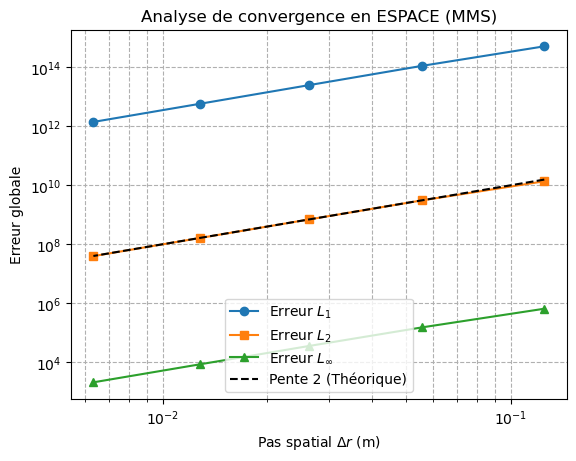

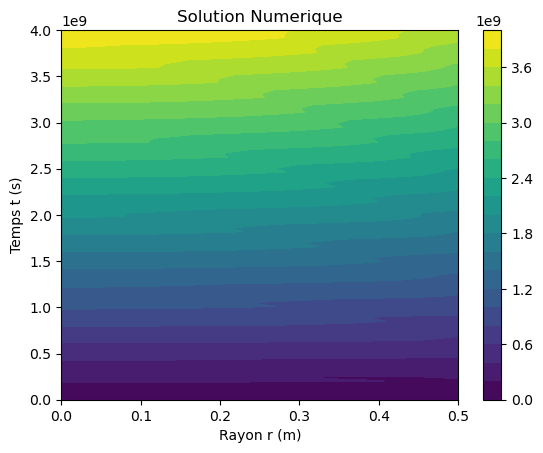

In [28]:
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.append('..') # Ajouter le dossier parent au path pour importer le module fdm_implicite

from fdm_implicite import solve_fdm_implicite

N = 100
T = 4e9
N_t = 100

R = 0.5

# Domaines 
r_dom = np.linspace(0, 0.5, N)
t_dom = np.linspace(0, T, N_t)
tii, rii = np.meshgrid(t_dom, r_dom)

# Evaluation de la solution numérique sur le domaine
C = solve_fdm_implicite(N, T, N_t)

#Analyse de convergeance en ESPACE
T_verif = 4e9
N_list = [5, 10, 20, 40, 80]
N_t_fixe = 1000

L1_err_espace = []
L2_err_espace = []
Linf_err_espace = []
dr_list = []

def exact_solution(r, t):
    return t * np.cos(r) + np.exp(r) * np.sin(t)

for N in N_list:
    C_num = solve_fdm_implicite(N, T_verif, N_t_fixe, D_EFF=1, K=4)

    r = np.linspace(0, R, N)
    t = np.linspace(0, T_verif, N_t_fixe)
    dr = r[1] - r[0]
    dt = t[1] - t[0]
    dr_list.append(dr)

    ti, ri = np.meshgrid(t, r)
    C_exact = exact_solution(ri, ti)
    
    erreur = np.abs(C_num - C_exact)

    # Add to error lists
    L1_err_espace.append(np.sum(erreur) * dr * dt)
    L2_err_espace.append(np.sqrt(np.sum(erreur**2) * dr * dt))
    Linf_err_espace.append(np.max(erreur))


pente_L1_espace = np.polyfit(np.log(dr_list[-2:]), np.log(L1_err_espace[-2:]), 1)[0]
pente_L2_espace = np.polyfit(np.log(dr_list[-2:]), np.log(L2_err_espace[-2:]), 1)[0]
pente_Linf_espace = np.polyfit(np.log(dr_list[-2:]), np.log(Linf_err_espace[-2:]), 1)[0]

print("Ordres de convergence observés en espace")
print(f"Pente L1      : {pente_L1_espace:.4f} ")
print(f"Pente L2      : {pente_L2_espace:.4f} ")
print(f"Pente L_inf   : {pente_Linf_espace:.4f}")

#Tracage de la convergence en espace
plt.figure()
plt.loglog(dr_list, L1_err_espace, 'o-', label='Erreur $L_1$')
plt.loglog(dr_list, L2_err_espace, 's-', label='Erreur $L_2$')
plt.loglog(dr_list, Linf_err_espace, '^-', label='Erreur $L_\\infty$')

dr_array = np.array(dr_list)
pente2 = L2_err_espace[2] * (dr_array / dr_array[2])**2
plt.loglog(dr_array, pente2, 'k--', label='Pente 2 (Théorique)')

plt.xlabel('Pas spatial $\\Delta r$ (m)')
plt.ylabel('Erreur globale')
plt.title('Analyse de convergence en ESPACE (MMS)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()




# Tracage de la solution numérique
plt.figure()
plt.contourf(rii, tii, C, levels=20)
plt.colorbar()
plt.title('Solution Numerique')
plt.xlabel('Rayon r (m)')
plt.ylabel('Temps t (s)')
plt.show()

Ordres de convergence observés en temps
Pente L1      : 0.9998 
Pente L2      : 0.9995 
Pente L_inf   : 0.9992


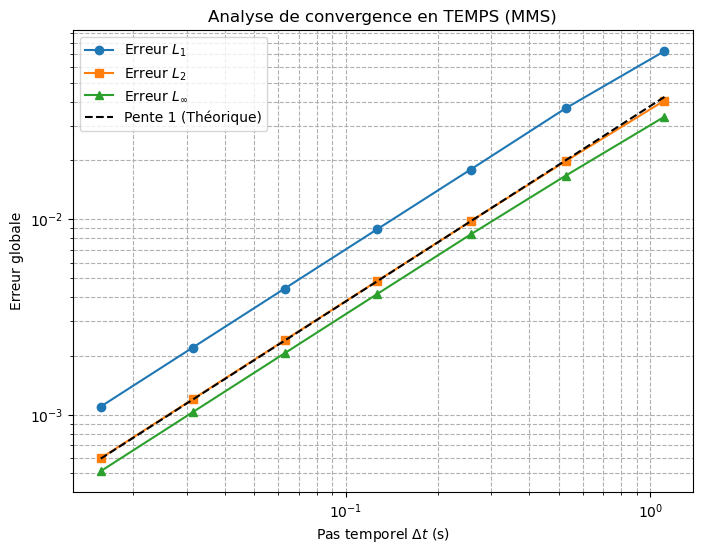

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from fdm_implicite import solve_fdm_implicite, R

T_verif = 10.0
Nt_list = [10, 20, 40, 80, 160, 320, 640]
N_fixe = 500

L1_err_temps = []
L2_err_temps = []
Linf_err_temps = []
dt_list = []

def exact_solution(r, t):
    return t * np.cos(r) + np.exp(r) * np.sin(t)

for N_t in Nt_list:
    C_num = solve_fdm_implicite(N_fixe, T_verif, N_t, D_EFF=1, K=4)
    r = np.linspace(0, R, N_fixe)
    t = np.linspace(0, T_verif, N_t)
    dr = r[1] - r[0]
    dt = t[1] - t[0]

    dt_list.append(dt)

    ti, ri = np.meshgrid(t, r)

    C_exact = exact_solution(ri, ti)
    erreur = np.abs(C_num - C_exact)
    
    L1 = np.sum(erreur) * dr * dt
    L2 = np.sqrt(np.sum(erreur**2) * dr * dt)
    Linf = np.max(erreur)
    
    L1_err_temps.append(L1)
    L2_err_temps.append(L2)
    Linf_err_temps.append(Linf) 

pente_L1_temps = np.polyfit(np.log(dt_list[-3:]), np.log(L1_err_temps[-3:]), 1)[0]
pente_L2_temps = np.polyfit(np.log(dt_list[-3:]), np.log(L2_err_temps[-3:]), 1)[0]
pente_Linf_temps = np.polyfit(np.log(dt_list[-3:]), np.log(Linf_err_temps[-3:]), 1)[0]
print("Ordres de convergence observés en temps")
print(f"Pente L1      : {pente_L1_temps:.4f} ")
print(f"Pente L2      : {pente_L2_temps:.4f} ")
print(f"Pente L_inf   : {pente_Linf_temps:.4f}")
plt.figure(figsize=(8, 6))
plt.loglog(dt_list, L1_err_temps, 'o-', label='Erreur $L_1$')
plt.loglog(dt_list, L2_err_temps, 's-', label='Erreur $L_2$')
plt.loglog(dt_list, Linf_err_temps, '^-', label='Erreur $L_\\infty$')
dt_array = np.array(dt_list)
pente1 = L2_err_temps[2] * (dt_array / dt_array[2])**1
plt.loglog(dt_array, pente1, 'k--', label='Pente 1 (Théorique)')

plt.xlabel('Pas temporel $\\Delta t$ (s)')
plt.ylabel('Erreur globale')
plt.title('Analyse de convergence en TEMPS (MMS)')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

#### F) obtenir et de tracer la solution du problème originel pour Ntot = 11 et pour t allant de $0$ à $4 \times 10^9 s$


**Réponse :** 



#### G) BONUS : réaliser l’analyse de convergence en temps ou en espace en écrivant un script Bash automatisé inspiré largement ou adapté de celui vu au Labo 2
